# Testing different activation functions and depths of neural network

In [1]:
# import OLS data 
from source.runge_preprocessing import x, y, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, y_train_std_ols, y_train_mean_ols, x_test, y_predicted_rescaled_ols


from source.utils import decide_activation_func, create_activations_layderdim
from source.runge_preprocessing import NP_RANDOM_SEED, ETA_VALUES
from source.neural_network import NN
from source.cost_functions import class_mse_loss
from source.plotting import plot_runges_two_predictions, plot_heatmap
from source.utils import neural_network_loop, decide_activation_func


In [2]:
# settings for FFNN

VERBOSE_FFNN = False
VERBOSE_ACTIVATIONS = True
VERBOSE = True
SAVE_FIGURE = True
SHOW_PLOT = True

ffnn_iterations = 100
batch_value = 256

cost_fn_ols = class_mse_loss(l1=0, l2=0)   # mse for regression, no penalty for L1 and L2 

LAMBDA_VALUES = [0]


JUST CHOOSE ONE OF THE DIMENSIONS FOR PLOTTING, CHANGE TITLE AND FILENAME FOR FIGURE BELOW
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 
Classification set: False
L1 and L2 term
0
0
Using scheduler: ADAM 


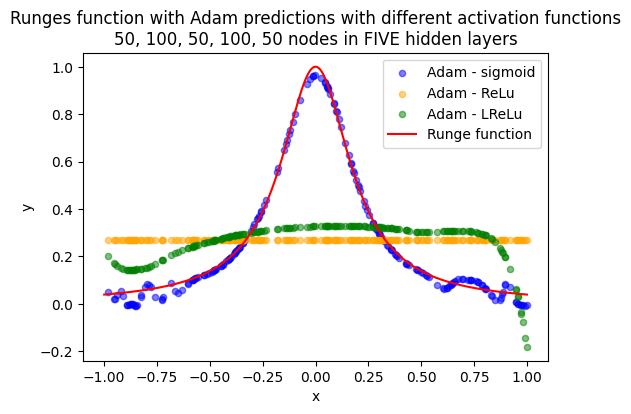

In [3]:
# computing and plotting specified hyperparameters for further analysis


print('JUST CHOOSE ONE OF THE DIMENSIONS FOR PLOTTING, CHANGE TITLE AND FILENAME FOR FIGURE BELOW')

# List if hidden layers to test
list_hidden_layers = [
    #(50, 100)
    (50, 100, 50, 100, 50)
]

# activation function to test
list_activation_functions = ['sigmoid', 'RELU', 'LRELU']




# processing variations

for hidden in list_hidden_layers:


        sigmoid_activaton_func, sigmoid_activaton_func_derivative, sigmoid_output_func, sigmoid_output_func_derivative = decide_activation_func('sigmoid')
        sigmoid_activations, sigmoid_activations_derivative, sigmoid__dim = create_activations_layderdim(sigmoid_activaton_func, sigmoid_activaton_func_derivative,
                                                                        sigmoid_output_func, sigmoid_output_func_derivative, 
                                                                        hidden, y_train_scaled_ols, X_train_scaled_ols)


        relu_activaton_func, relu_activaton_func_derivative, relu_output_func, relu_output_func_derivative = decide_activation_func('RELU')
        relu_activations, relu_activations_derivative, relu__dim = create_activations_layderdim(relu_activaton_func, relu_activaton_func_derivative,
                                                                        relu_output_func, relu_output_func_derivative, 
                                                                        hidden, y_train_scaled_ols, X_train_scaled_ols)
        
        lrelu_activaton_func, lrelu_activaton_func_derivative, lrelu_output_func, lrelu_output_func_derivative = decide_activation_func('LRELU')
        lrelu_activations, lrelu_activations_derivative, lrelu__dim = create_activations_layderdim(lrelu_activaton_func, lrelu_activaton_func_derivative,
                                                                        lrelu_output_func, lrelu_output_func_derivative, 
                                                                        hidden, y_train_scaled_ols, X_train_scaled_ols)


        
        def model_fn_sigmoid():
            return NN(sigmoid__dim, list(sigmoid_activations), list(sigmoid_activations_derivative), cost_fn_ols, NP_RANDOM_SEED)

        def model_fn_relu():
            return NN(relu__dim, list(relu_activations), list(relu_activations_derivative), cost_fn_ols, NP_RANDOM_SEED)

        def model_fn_lrelu():
            return NN(lrelu__dim, list(lrelu_activations), list(lrelu_activations_derivative), cost_fn_ols, NP_RANDOM_SEED)


        # ADAM
        rho_val = 0.9
        rho2_val = 0.999
        ADAM_results_sigmoid = neural_network_loop(model_fn_sigmoid, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 
        ADAM_results_relu = neural_network_loop(model_fn_relu, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 
        ADAM_results_lrelu = neural_network_loop(model_fn_lrelu, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 



        # Save heatmaps for analysis
        if SAVE_FIGURE:

            task = 'part_d'
            algo = 'ownNN'
            plot_type = 'heatmap'
            plot_type_runge = 'runge-activations'

            #filename_values = f'{task}-{plot_type}-{hidden}-activation{act_f}-iter{ffnn_iterations}-batch{batch_value}-{algo}'


            #plot_heatmap(ADAM_results, 'MSE test', y_axis_scientific=False, show_plot=SHOW_PLOT, title=f'Heatmap with MSE values for ADAM - {act_f}', filename = 'adam_' + filename_values)

            
            from source.utils import rescale_predictions

            ADAM_best_rescaled_pred_sigmoid = rescale_predictions(ADAM_results_sigmoid, y_train_std_ols, y_train_mean_ols)
            ADAM_best_rescaled_pred_relu = rescale_predictions(ADAM_results_relu, y_train_std_ols, y_train_mean_ols)
            ADAM_best_rescaled_pred_lrelu = rescale_predictions(ADAM_results_lrelu, y_train_std_ols, y_train_mean_ols)

            filename_values = f'{task}-{plot_type_runge}-{hidden}--iter{ffnn_iterations}-batch{batch_value}-{algo}'

            from source.plotting import plot_runges_three_predictions
            plot_runges_three_predictions(x, y, x_test, ADAM_best_rescaled_pred_sigmoid,
                            x_test, ADAM_best_rescaled_pred_relu, x_test, ADAM_best_rescaled_pred_lrelu, 
                                label_scatter1='Adam - sigmoid', label_scatter2='Adam - ReLu', label_scatter3='Adam - LReLu', 
                                alpha_val=0.5, title='Runges function with Adam predictions with different activation functions\n50, 100, 50, 100, 50 nodes in FIVE hidden layers',
                                filename='part_d -- Runges function with Adam predictions with different activation functions - 50, 100, 50, 100, 50 nodes in FIVE')
            
                                                                                                                            


In [ ]:
# Process many variation to see which were interesting for further analysis




# List if hidden layers to test

PROCESS_ALL_VARIATIONS = False

if PROCESS_ALL_VARIATIONS:
    list_hidden_layers = [
        (8,),
        (16,),
        (50,),
        (8, 16),
        (50, 100),
        (16, 32, 16),
        (50, 100, 50, 100, 50)
    ]

    # activation function to test
    list_activation_functions = ['sigmoid', 'RELU', 'LRELU']


In [5]:
# processing variations

if PROCESS_ALL_VARIATIONS:

    for hidden in list_hidden_layers:
        for act_f in list_activation_functions:

            activaton_func, activaton_func_derivative, output_func, output_func_derivative = decide_activation_func(act_f)
            activations, activations_derivative, _dim = create_activations_layderdim(activaton_func, activaton_func_derivative,
                                                                            output_func, output_func_derivative, 
                                                                            hidden, y_train_scaled_ols, X_train_scaled_ols)
            
            def model_fn():
                return NN(_dim, list(activations), list(activations_derivative), cost_fn_ols, NP_RANDOM_SEED)

            if VERBOSE_ACTIVATIONS:
                print()
                print(f'Activation layers: {activations}\nand their derivatives: {activations_derivative}\nDimensions if input, hidden layers and output layer: {_dim}')


            # ADAM
            rho_val = 0.9
            rho2_val = 0.999
            ADAM_results = neural_network_loop(model_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, batch_val=batch_value, rho=rho_val, rho2=rho2_val, verbose=VERBOSE_FFNN) 


            # Save heatmaps for analysis
            if SAVE_FIGURE:

                task = 'part_d'
                algo = 'ownNN'
                plot_type = 'heatmap'
                plot_type_runge = 'runge'

                filename_values = f'{task}-{plot_type}-{hidden}-activation{act_f}-iter{ffnn_iterations}-batch{batch_value}-{algo}'


                plot_heatmap(ADAM_results, 'MSE test', y_axis_scientific=False, show_plot=SHOW_PLOT, title=f'Heatmap with MSE values for ADAM - {act_f}', filename = 'adam_' + filename_values)

                
                from source.utils import pytorch_loop, rescale_predictions

                ADAM_best_rescaled_pred = rescale_predictions(ADAM_results, y_train_std_ols, y_train_mean_ols)
                filename_values = f'{task}-{plot_type_runge}-{hidden}-activation{act_f}-iter{ffnn_iterations}-batch{batch_value}-{algo}'
                
                plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, ADAM_best_rescaled_pred,
                                                                label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                                alpha_val=0.5, title=f'Runges function with OLS and FFNN predictions - {act_f}',
                                                                filename='adam_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)